# Validação externa e mapa dos perfis

Este notebook verifica se os perfis encontrados na clusterização dizem algo
sobre os municípios que não foi usado para formá-los, e mostra onde cada
perfil se localiza no estado. Responde à parte de caracterização da pergunta
(iii) do artigo.

Saídas:

- **Figura 6** do artigo (`figura6_mapa_perfis`): o mapa dos perfis;
- `data/processed/tabela_kruskal.csv`: o teste de Kruskal–Wallis e o tamanho
  de efeito ε² da variável de validação externa e das 22 features;
- figura de apoio: `figura_via_publica_perfis`.

**Critério definido antes da execução.** A validação externa é feita apenas
com `prop_via_publica` (proporção de ocorrências em via pública), que não
entrou na modelagem. O mesmo teste aplicado às 22 features é descritivo e
circular, uma vez que foram essas variáveis que formaram os perfis.

A seção 0 confere a malha municipal do IBGE e não depende do modelo
escolhido. As seções 1 a 4 dependem do `perfis.csv`, gerado pelo notebook 05
depois da escolha do modelo pelo grupo.

In [1]:
import sys
from pathlib import Path

import pandas as pd

# Os notebooks ficam em notebooks/ e o código do projeto em src/. Estas duas
# linhas apontam o Python para src/, para os "from config import ..." abaixo
# funcionarem tanto rodando daqui quanto da raiz do projeto.
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))

from config import (ALGORITMO_ESCOLHIDO, BASE_FINAL_CSV, DATA_PROCESSED,
                    DICIONARIO_CSV, K_ESCOLHIDO)
from estilo import aplicar_estilo, salvar
from figuras import plot_boxplot_perfis, plot_mapa_categorias
from malha import carregar_malha_sp
from preprocessamento import carregar_features
from clusterizacao import faixa_epsilon2, kruskal_epsilon2

aplicar_estilo()   # mesma fonte, cores e grade em todas as figuras do artigo
# Se algum import acima falhar, quase sempre é o editor apontando para outra
# instalação do Python. O caminho impresso aqui é o que precisa ter as
# bibliotecas do requirements.txt.
print("Python:", sys.executable)
print(f"Modelo escolhido: {ALGORITMO_ESCOLHIDO}, k = {K_ESCOLHIDO}")

# O código do IBGE é identificador, não quantidade: lido como texto para não
# virar número em nenhuma etapa.
base = pd.read_csv(BASE_FINAL_CSV, dtype={"codigo_ibge": str})
dic = pd.read_csv(DICIONARIO_CSV)
perfis = pd.read_csv(DATA_PROCESSED / "perfis.csv", dtype={"codigo_ibge": str})

Python: D:\RP 2\database-rp2\.venv\Scripts\python.exe
Modelo escolhido: kmeans, k = 4


## 0. Conferência da malha municipal

A malha municipal é o desenho do contorno de cada município, publicado pelo
IBGE. Ela é obtida da API de malhas do IBGE na primeira execução e guardada
em `data/raw/ibge/malha_sp_municipios.geojson`; nas execuções seguintes, é
lida do disco. A junção com a base é feita pelo código IBGE, como em todo o
projeto.

In [2]:
malha = carregar_malha_sp()

# Todo município da base precisa ter um contorno na malha; senão ele some do
# mapa sem nenhum aviso.
faltando = set(base["codigo_ibge"]) - set(malha["codigo_ibge"])
assert not faltando, f"municípios da base sem polígono na malha: {faltando}"
print(f"{len(malha)} polígonos na malha | {base['codigo_ibge'].nunique()} "
      "municípios da base, todos encontrados")

645 polígonos na malha | 645 municípios da base, todos encontrados


O mapa abaixo serve apenas para conferir a junção e não é salvo. A taxa
de urbanização é dividida em quatro faixas com o mesmo número de municípios
(quartis), e cada faixa recebe um tom de azul. Uma junção errada produziria
municípios em branco ou um padrão espacial sem relação com o conhecido.

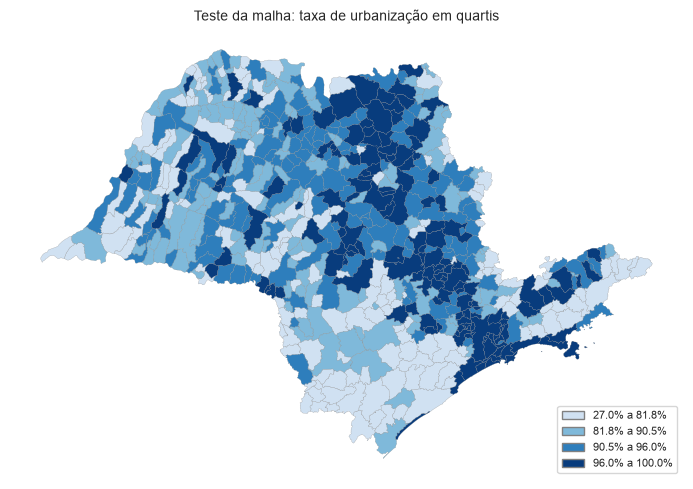

In [3]:
# pd.qcut divide em faixas com o mesmo número de municípios em cada uma;
# retbins=True devolve também os limites, que usamos na legenda.
faixa, limites = pd.qcut(base["taxa_urbanizacao"], 4, labels=False,
                         retbins=True)
teste = malha.merge(base[["codigo_ibge"]].assign(faixa=faixa + 1),
                    on="codigo_ibge", how="left")
rotulos = {i + 1: f"{limites[i]:.1f}% a {limites[i + 1]:.1f}%"
           for i in range(4)}
fig = plot_mapa_categorias(teste, "faixa", rotulos,
                           "Teste da malha: taxa de urbanização em quartis")

## 1. Validação externa

O teste de Kruskal–Wallis verifica se uma variável muda de um perfil para
outro. Ele ordena os 644 municípios pelo valor da variável e compara as
posições médias de cada perfil: se os perfis não diferissem, as posições
médias seriam parecidas. O resultado é a estatística H e o seu p-valor.

Com 644 municípios, quase qualquer diferença, mesmo pequena, produz um
p-valor muito baixo. Por isso a leitura se apoia no **tamanho de efeito**
ε² = H / (n − 1), que vai de 0 (a variável não muda entre os perfis) a 1 (a
variável separa completamente os perfis). As faixas adotadas para a leitura
são: abaixo de 0,04, fraco; de 0,04 a 0,16, moderado; de 0,16 a 0,36,
relativamente forte; de 0,36 a 0,64, forte [CITAÇÃO?].

A variável testada é a `prop_via_publica`, a proporção das ocorrências de
cada município registradas em via pública. Ela não entrou na modelagem; se
os perfis diferem nela, eles capturam algo sobre os municípios que vai além
das 22 variáveis usadas para formá-los.

In [4]:
# Mesmo filtro e mesma ordem do notebook 05 (sem a capital, que não tem IEGM).
modelagem = base[~base["flag_sem_iegm"]].reset_index(drop=True)
assert (modelagem["codigo_ibge"] == perfis["codigo_ibge"]).all(), \
    "perfis.csv fora da ordem da base"
perfil = perfis["perfil"]

H, p_valor, epsilon2 = kruskal_epsilon2(modelagem["prop_via_publica"], perfil)
print(f"prop_via_publica: H = {H:.1f} | p-valor = {p_valor:.1e} | "
      f"epsilon² = {epsilon2:.3f} ({faixa_epsilon2(epsilon2)})")

# Mediana por perfil, em %, para dizer em que direção está a diferença.
(100 * modelagem.groupby(perfil)["prop_via_publica"].median()).round(1)

prop_via_publica: H = 229.2 | p-valor = 2.0e-49 | epsilon² = 0.356 (relativamente forte)


perfil
1    33.1
2    30.0
3    41.3
4    48.4
Name: prop_via_publica, dtype: float64

WindowsPath('D:/RP 2/database-rp2/figuras/figura_via_publica_perfis.png')

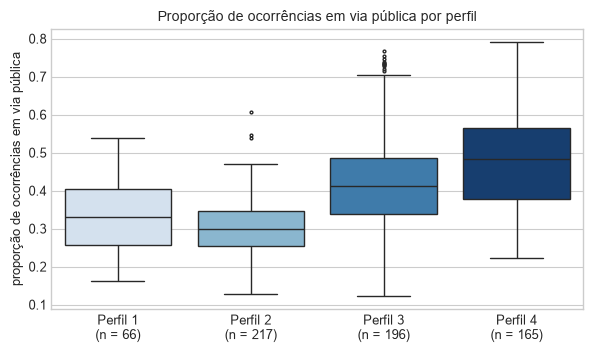

In [5]:
n_por_perfil = perfil.value_counts().sort_index()
rotulos_perfis = [f"Perfil {p}\n(n = {n})" for p, n in n_por_perfil.items()]
fig = plot_boxplot_perfis(modelagem["prop_via_publica"], perfil,
                          "proporção de ocorrências em via pública",
                          rotulos_perfis)
salvar(fig, "figura_via_publica_perfis")

O ε² da `prop_via_publica` é de 0,356, na faixa relativamente forte e
próximo do seu limite superior (0,36). A proporção mediana de ocorrências em
via pública é menor nos perfis 2 (30,0%) e 1 (33,1%) e maior nos perfis 3
(41,3%) e 4 (48,4%): nos perfis mais urbanos, uma parcela maior dos crimes
registrados acontece na rua.

A célula abaixo verifica o quanto a variável externa se relaciona com as
features que formaram os perfis.

In [6]:
features, bloco_de = carregar_features(dic)
# corrwith calcula a correlação de cada feature com a variável externa;
# key=abs ordena pelo tamanho da correlação, sem olhar o sinal.
rho = modelagem[features].corrwith(modelagem["prop_via_publica"],
                                   method="spearman")
rho.sort_values(key=abs, ascending=False).head(6).round(2)

taxa_roubo_outros     0.68
taxa_furto_veiculo    0.65
prop_lixo_coletado    0.64
taxa_roubo_veiculo    0.63
taxa_alfabetizacao    0.61
taxa_urbanizacao      0.60
dtype: float64

A `prop_via_publica` não entrou na modelagem, mas não é independente das
features: a correlação de Spearman com elas chega a 0,68 (taxa de roubo de
outros), seguida de 0,65 (furto de veículo), 0,64 (coleta de lixo), 0,63
(roubo de veículo), 0,61 (alfabetização) e 0,60 (urbanização). Parte da
diferença entre os perfis nessa variável reflete, portanto, as diferenças em
roubo e urbanização que formaram os perfis. O resultado mostra que os perfis
se mantêm coerentes em uma variável que não participou do agrupamento, mas a
validação é mais fraca do que seria com uma variável sem relação com as
features, ressalva que deve acompanhar o resultado no artigo.

## 2. Quais variáveis mais separam os perfis

O mesmo teste é aplicado às 22 features. **Este resultado é descritivo, e
não uma validação**: as features formaram os perfis, de modo que diferenças
grandes entre eles são esperadas por construção. A tabela serve para
identificar as variáveis que mais distinguem os perfis e apoiar a escolha
dos nomes. Os valores originais da base são usados sem transformação, pois o
teste considera apenas a ordem dos municípios, que o `log1p` e a
padronização não alteram.

In [7]:
linhas = [{"variavel": "prop_via_publica", "tipo": "validacao_externa",
           "H": H, "p_valor": p_valor, "epsilon2": epsilon2}]
for f in features:
    H_f, p_f, e_f = kruskal_epsilon2(modelagem[f], perfil)
    linhas.append({"variavel": f, "tipo": "feature",
                   "H": H_f, "p_valor": p_f, "epsilon2": e_f})
tabela_kruskal = pd.DataFrame(linhas)
assert len(tabela_kruskal) == 23, "deveriam ser 1 variável externa + 22 features"
tabela_kruskal.to_csv(DATA_PROCESSED / "tabela_kruskal.csv", index=False)

# Para mostrar: as features em ordem de epsilon², com bloco e faixa.
mostrar = tabela_kruskal[tabela_kruskal["tipo"] == "feature"].copy()
mostrar["bloco"] = mostrar["variavel"].map(bloco_de)
mostrar["faixa"] = mostrar["epsilon2"].map(faixa_epsilon2)
(mostrar.sort_values("epsilon2", ascending=False)
 [["variavel", "bloco", "H", "p_valor", "epsilon2", "faixa"]]
 .round({"H": 1, "epsilon2": 3}).reset_index(drop=True))

,variavel,bloco,H,p_valor,epsilon2,faixa
0,taxa_alfabetizacao,socioeconomico,318.0,1.288658e-68,0.494,forte
1,taxa_urbanizacao,socioeconomico,315.3,4.843860e-68,0.490,forte
2,taxa_roubo_outros,criminalidade,275.1,2.466754e-59,0.428,forte
3,prop_lixo_coletado,socioeconomico,271.1,1.761602e-58,0.422,forte
4,taxa_roubo_veiculo,criminalidade,250.0,6.483345e-54,0.389,forte
5,taxa_furto_veiculo,criminalidade,249.8,7.064749e-54,0.389,forte
6,i_gov_ti_ord,gestao,232.2,4.734567e-50,0.361,forte
7,prop_esgoto_adequado,socioeconomico,213.7,4.623013e-46,0.332,relativamente forte
8,i_cidade_ord,gestao,207.3,1.100165e-44,0.322,relativamente forte
9,renda_domiciliar_mediana,socioeconomico,185.4,6.132465e-40,0.288,relativamente forte


As variáveis que mais separam os perfis são a alfabetização (ε² de 0,494)
e a urbanização (0,490), seguidas da taxa de roubo de outros (0,428) e da
coleta de lixo (0,422). As sete variáveis com efeito forte vêm dos três
blocos: três socioeconômicas, três criminais (roubo de outros, roubo de
veículo e furto de veículo) e uma de gestão (governança de tecnologia da
informação, 0,361). Os crimes contra a pessoa separam pouco os perfis: CVLI
(0,057), estupro (0,089) e lesão dolosa (0,090) ficam na faixa moderada, e a
tentativa de homicídio (0,030), na fraca, assim como a nota de planejamento
do IEGM (0,035), em que 70% dos municípios têm o mesmo valor. Os perfis se
distinguem, portanto, pela criminalidade patrimonial, e não pela violência
contra a pessoa.

## 3. Figura 6 - mapa dos perfis

Os perfis são unidos à malha municipal pelo código IBGE. A capital, fora da
modelagem por não ter IEGM, aparece com hachura.

WindowsPath('D:/RP 2/database-rp2/figuras/figura6_mapa_perfis.png')

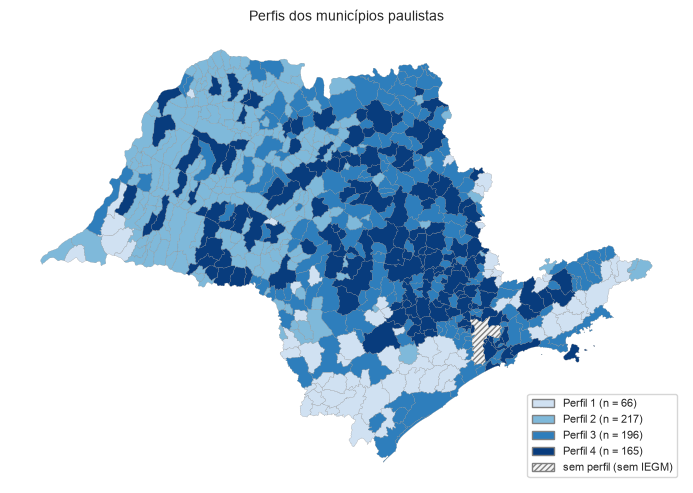

In [8]:
mapa = malha.merge(perfis[["codigo_ibge", "perfil"]], on="codigo_ibge",
                   how="left")
# Os 644 municípios com perfil precisam ter achado um polígono; o único sem
# perfil deve ser a capital.
assert mapa["perfil"].notna().sum() == len(perfis) == 644, "perfil sem polígono"
assert set(mapa.loc[mapa["perfil"].isna(), "codigo_ibge"]) == {"3550308"}

rotulos_mapa = {p: f"Perfil {p} (n = {n})" for p, n in n_por_perfil.items()}
fig = plot_mapa_categorias(mapa, "perfil", rotulos_mapa,
                           "Perfis dos municípios paulistas")
salvar(fig, "figura6_mapa_perfis")

## 4. Leitura do mapa

A célula abaixo confere o perfil de cada município citado no texto desta
seção.

In [9]:
citados = {
    1: ["Eldorado", "Iporanga", "Barra do Turvo", "Ribeirão Branco", "Guapiara",
        "Cunha", "São Luiz do Paraitinga", "Areias"],
    2: ["Taciba", "Tabapuã", "General Salgado", "Teodoro Sampaio", "Rosana"],
    3: ["Carapicuíba", "Itaquaquecetuba", "Francisco Morato", "Embu das Artes",
        "Guarujá", "São Vicente", "Caraguatatuba", "Ubatuba", "Guaratinguetá",
        "Lorena"],
    4: ["Campinas", "Sorocaba", "Piracicaba", "Ribeirão Preto",
        "Presidente Prudente", "Araçatuba", "São José do Rio Preto", "Marília",
        "Santo André", "São Bernardo do Campo", "São Caetano do Sul",
        "Guarulhos", "Osasco", "Barueri", "Santos"],
}
assert perfis["municipio"].is_unique, "nome de município repetido"
perfil_de = perfis.set_index("municipio")["perfil"]
for p, nomes in citados.items():
    fora = [m for m in nomes if perfil_de[m] != p]
    assert not fora, f"citados no perfil {p}, mas estão em outro: {fora}"
print("todos os municípios citados estão no perfil indicado")

todos os municípios citados estão no perfil indicado


Os perfis têm uma geografia nítida.

- **Perfil 1** concentra-se no sul do estado, no Vale do Ribeira (Eldorado,
  Iporanga, Barra do Turvo) e na região de Itapeva (Ribeirão Branco,
  Guapiara), e no extremo leste, entre o Vale do Paraíba e a divisa com o
  Rio de Janeiro (Cunha, São Luiz do Paraitinga, Areias).
- **Perfil 2** ocupa a maior parte do oeste e do noroeste, com os pequenos
  municípios em torno dos polos regionais (Taciba, Tabapuã, General Salgado)
  e parte do Pontal do Paranapanema (Teodoro Sampaio, Rosana).
- **Perfil 3** reúne a periferia da Grande São Paulo (Carapicuíba,
  Itaquaquecetuba, Francisco Morato, Embu das Artes), a maior parte do
  litoral (Guarujá, São Vicente, Caraguatatuba, Ubatuba) e cidades médias
  do Vale do Paraíba (Guaratinguetá, Lorena).
- **Perfil 4** reúne os polos regionais do interior, tanto no eixo
  Campinas–Sorocaba–Piracicaba–Ribeirão Preto quanto no oeste (Presidente
  Prudente, Araçatuba, São José do Rio Preto, Marília), e o núcleo mais rico
  da Grande São Paulo e da Baixada Santista (Santo André, São Bernardo do
  Campo, São Caetano do Sul, Guarulhos, Osasco, Barueri, Santos).

Na Grande São Paulo, os perfis 3 e 4 se alternam: os municípios do núcleo
metropolitano ficam no perfil 4 e os da periferia, no perfil 3, que
combina crime patrimonial acima da média com gestão abaixo da média.